# ASTR 223 Final Project: Projection Model Implementation

Some source code taken from: 
* https://num.pyro.ai/en/stable/examples/baseball.html

In [126]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pybaseball import batting_stats

import re
import unicodedata

import argparse
import os

import powerlaw

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option('display.max_columns', None)

## modeling libraries
import jax
import jax.numpy as jnp
import jax.random as random
from jax.scipy.special import logit, expit, logsumexp


import numpyro
import numpyro.distributions as dist
from numpyro.examples.datasets import load_dataset
from numpyro.infer import HMC, MCMC, NUTS, SA, Predictive, log_likelihood
from numpyro.infer.mcmc import MCMC

import patsy

import arviz as az

from scipy.stats import pearsonr

blue_color = '#1E90FF'
red_color = '#EF3E42'
color_palette = {0: blue_color, 1: red_color}

In [127]:
seed = 42
key = jax.random.key(seed)
numpyro.set_host_device_count(6)
jax.config.update("jax_enable_x64", True) ## makes the arrays a little more precise

In [128]:
batted_ball_data = pd.read_parquet('../data/batted_balls_w_xhrs.parquet')
player_data = pd.read_parquet('../data/player_primary_pos_w_xhrs.parquet')

## this is our goal --> we're doing it by batted ball events not just plate appearences b/c we modeled xHRs with just EV and LA
player_data['xHR%'] = player_data['xHR'] / player_data['events']

possible_pos = ['C', '1B', '2B', '3B', 'SS', 'LF', 'CF', 'RF', 'DH']

In [129]:
# these are HR ballpark factors
ballpark_factors = {
    'ARI': {2020: 112, 2021: 89, 2022: 86, 2023: 84, 2024: 86, 2025: 88},
    # 2025 for ATH is 100 b/c they played in SAC
    'ATH': {2020: 85, 2021: 85, 2022: 80, 2023: 84, 2024: 81, 2025: 100},
    'ATL': {2020: 94, 2021: 103, 2022: 104, 2023: 111, 2024: 105, 2025: 104},
    'BAL': {2020: 118, 2021: 124, 2022: 108, 2023: 104, 2024: 93, 2025: 105},
    'BOS': {2020: 92, 2021: 91, 2022: 99, 2023: 99, 2024: 98, 2025: 89},
    'CHC': {2020: 92, 2021: 104, 2022: 103, 2023: 106, 2024: 93, 2025: 99},
    'CHW': {2020: 107, 2021: 113, 2022: 113, 2023: 104, 2024: 98, 2025: 96},
    'CIN': {2020: 106, 2021: 126, 2022: 139, 2023: 131, 2024: 128, 2025: 123},
    'CLE': {2020: 101, 2021: 102, 2022: 98, 2023: 89, 2024: 86, 2025: 85},
    'COL': {2020: 118, 2021: 112, 2022: 108, 2023: 108, 2024: 109, 2025: 106},
    'DET': {2020: 93, 2021: 84, 2022: 76, 2023: 79, 2024: 86, 2025: 99},
    'HOU': {2020: 106, 2021: 106, 2022: 100, 2023: 101, 2024: 107, 2025: 105},
    'KCR': {2020: 80, 2021: 76, 2022: 80, 2023: 84, 2024: 85, 2025: 85},
    'LAA': {2020: 112, 2021: 107, 2022: 114, 2023: 112, 2024: 112, 2025: 113},
    'LAD': {2020: 119, 2021: 124, 2022: 126, 2023: 122, 2024: 122, 2025: 127},
    'MIA': {2020: 74, 2021: 81, 2022: 84, 2023: 86, 2024: 92, 2025: 90},
    'MIL': {2020: 110, 2021: 105, 2022: 110, 2023: 109, 2024: 114, 2025: 106},
    'MIN': {2020: 93, 2021: 99, 2022: 100, 2023: 104, 2024: 105, 2025: 102},
    'NYM': {2020: 105, 2021: 102, 2022: 95, 2023: 95, 2024: 99, 2025: 104},
    'NYY': {2020: 115, 2021: 111, 2022: 115, 2023: 116, 2024: 119, 2025: 119},
    'PHI': {2020: 116, 2021: 114, 2022: 113, 2023: 113, 2024: 115, 2025: 114},
    'PIT': {2020: 84, 2021: 81, 2022: 84, 2023: 80, 2024: 84, 2025: 76},
    'SDP': {2020: 99, 2021: 98, 2022: 100, 2023: 93, 2024: 104, 2025: 102},
    'SFG': {2020: 74, 2021: 79, 2022: 83, 2023: 84, 2024: 78, 2025: 82},
    'SEA': {2020: 100, 2021: 99, 2022: 100, 2023: 98, 2024: 96, 2025: 93},
    'STL': {2020: 86, 2021: 81, 2022: 84, 2023: 90, 2024: 91, 2025: 87},
    # 2025 for TBR is 100 b/c they played at steinbrenner field
    'TBR': {2020: 83, 2021: 84, 2022: 87, 2023: 94, 2024: 98, 2025: 100},
    # 2020-2021 for TEX is 100 b/c they hadn't played full seasons at globe field yet (opened in 2019)
    'TEX': {2020: 100, 2021: 100, 2022: 101, 2023: 111, 2024: 115, 2025: 104},
    'TOR': {2020: 117, 2021: 117, 2022: 111, 2023: 104, 2024: 103, 2025: 104}, 
    'WSN': {2020: 111, 2021: 109, 2022: 108, 2023: 107, 2024: 101, 2025: 94},
    # this handles all of the players who played for multiple teams in a single season --> easy way to account for them 
    '--': {2020: 100, 2021: 100, 2022: 100, 2023: 100, 2024: 100, 2025: 100},
    }
ballpark_data = pd.DataFrame(ballpark_factors).T.reset_index(names='team')
park_long = ballpark_data.melt(id_vars='team', var_name='game_year', value_name='park_factor')
park_long['park_factor'] = park_long['park_factor'] / 100.0
## we add 1 because each year is associated with the next year for the projection (2020 meant 2018-2020 to be used for 2021, and so on)
park_long['game_year'] = park_long['game_year'] + 1

## EDA

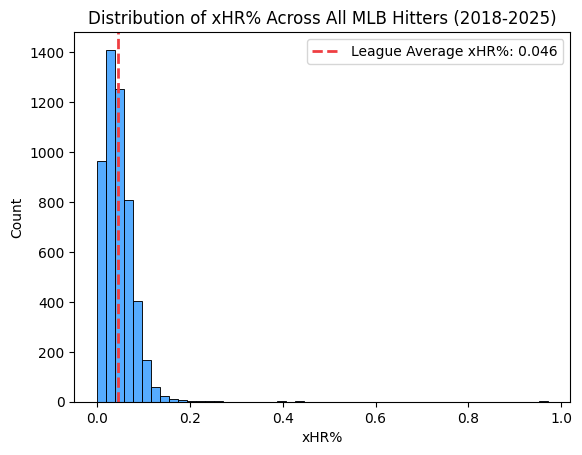

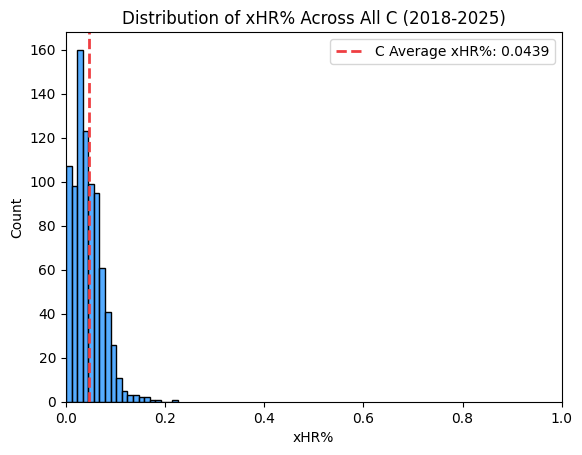

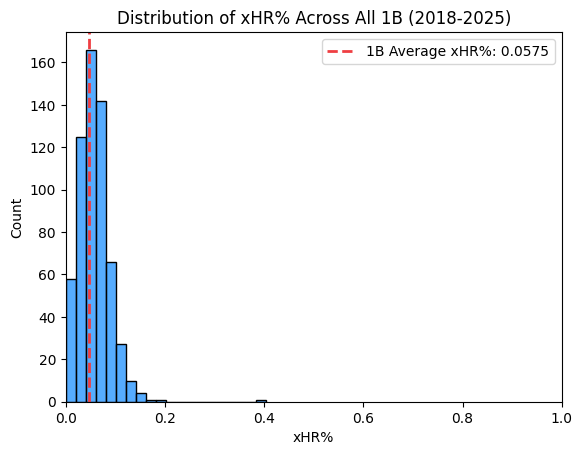

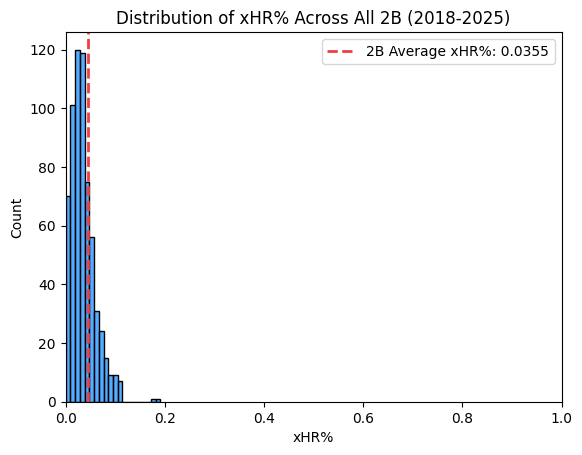

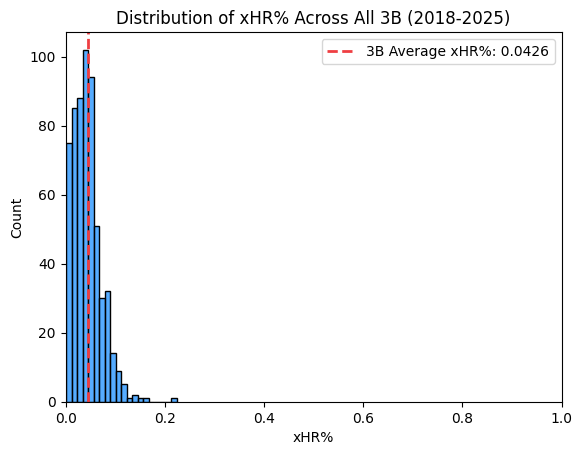

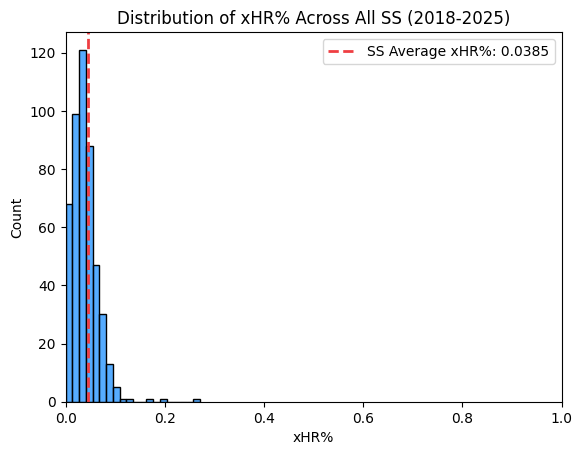

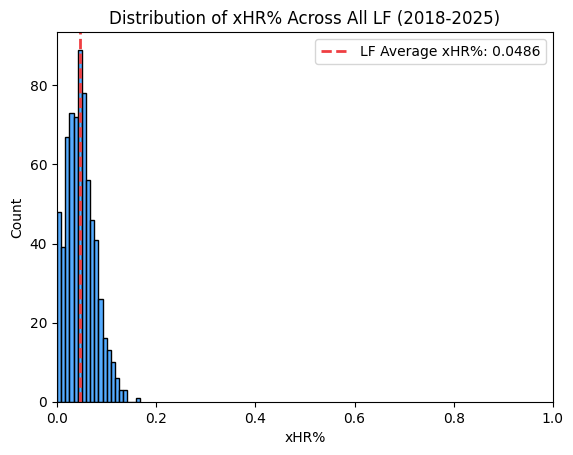

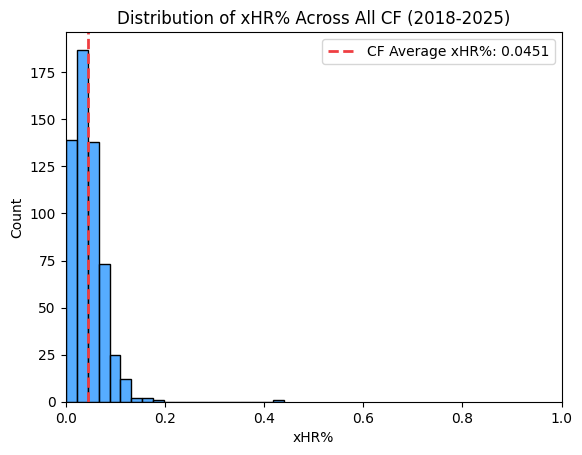

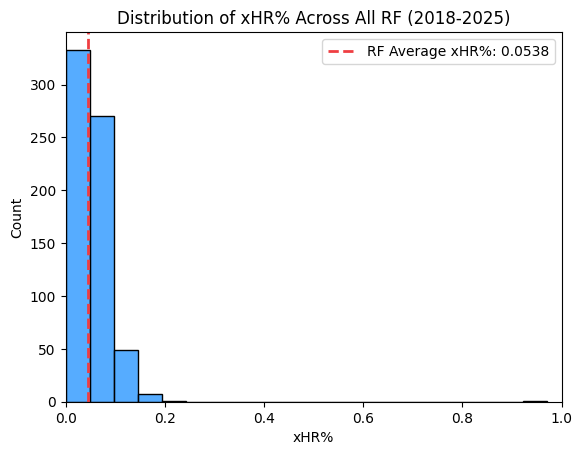

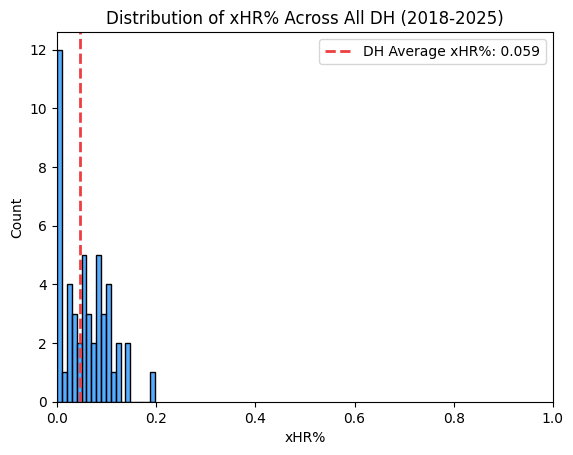

,count,mean,std,min,25%,50%,75%,max
primary_pos,,,,,,,,
C,839.0,0.043871,0.030043,0.000276,0.023145,0.039210,0.060950,0.225747
1B,601.0,0.057455,0.032986,0.000610,0.036908,0.053758,0.075295,0.404004
2B,638.0,0.035512,0.024344,0.000085,0.018380,0.031136,0.046668,0.190884
3B,591.0,0.042628,0.028122,0.000643,0.021080,0.039290,0.056321,0.223590
SS,476.0,0.038510,0.026567,0.000157,0.021499,0.034306,0.051691,0.271213
LF,687.0,0.048612,0.028428,0.000315,0.028083,0.046167,0.066348,0.167055
CF,580.0,0.045072,0.033262,0.000501,0.023172,0.040892,0.060310,0.440163
RF,661.0,0.053779,0.048282,0.000300,0.029925,0.048245,0.070615,0.971081
DH,50.0,0.059040,0.047322,0.000483,0.021072,0.055999,0.090796,0.197255


Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 5121/5121 [00:08<00:00, 582.36it/s] 


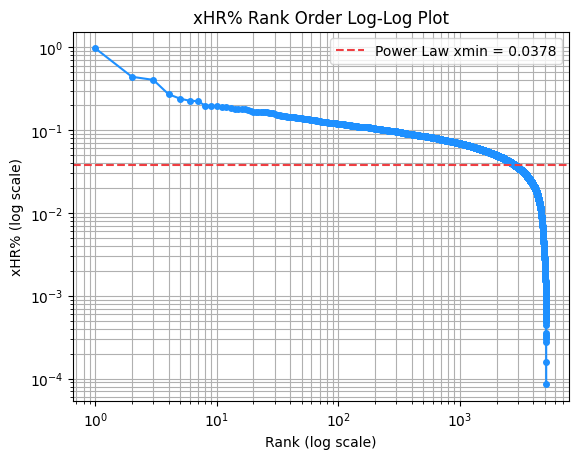

In [130]:
# some EDA on the distribution of xHR%

plt.figure()
sns.histplot(data=player_data, x='xHR%', color=blue_color, bins=50,)
plt.title('Distribution of xHR% Across All MLB Hitters (2018-2025)')
plt.axvline(x=player_data['xHR%'].mean(), color=red_color, linewidth = 2, linestyle='--', label=rf'League Average xHR%: {player_data['xHR%'].mean():.3}')
plt.legend()
plt.show()

for pos in possible_pos:
    pos_data = player_data[player_data['primary_pos'] == pos]
    plt.figure()
    sns.histplot(data=pos_data, x='xHR%', color=blue_color, bins=20,)
    plt.title(f'Distribution of xHR% Across All {pos} (2018-2025)')
    plt.axvline(x=player_data['xHR%'].mean(), color=red_color, linewidth = 2, linestyle='--', label=rf'{pos} Average xHR%: {pos_data['xHR%'].mean():.3}')
    plt.legend()
    plt.xlim(0, 1)
    plt.show()

display(player_data.groupby('primary_pos')['xHR%'].describe().reindex(possible_pos))

sorted_xhrs = np.sort(player_data['xHR%'])[::-1]
xhr_ranks = np.arange(1, len(sorted_xhrs) + 1)
fit = powerlaw.Fit(sorted_xhrs)
xmin = fit.power_law.xmin
plt.figure()
plt.loglog(xhr_ranks, sorted_xhrs, marker='o', linestyle='-', markersize=4, color=blue_color)
plt.axhline(xmin, label=f'Power Law xmin = {xmin:.4f}', color=red_color, linestyle='--')
plt.xlabel('Rank (log scale)')
plt.ylabel('xHR% (log scale)')
plt.title(f'xHR% Rank Order Log-Log Plot')
plt.grid(True, which="both", ls="-")
# plt.xlim(1, len(sorted_xhrs))
# plt.ylim(min(sorted_xhrs)*0.9, max(sorted_xhrs)*1.1)
plt.legend()
plt.show()

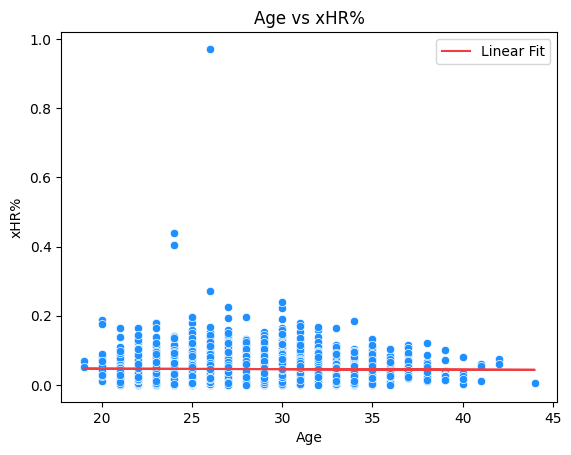

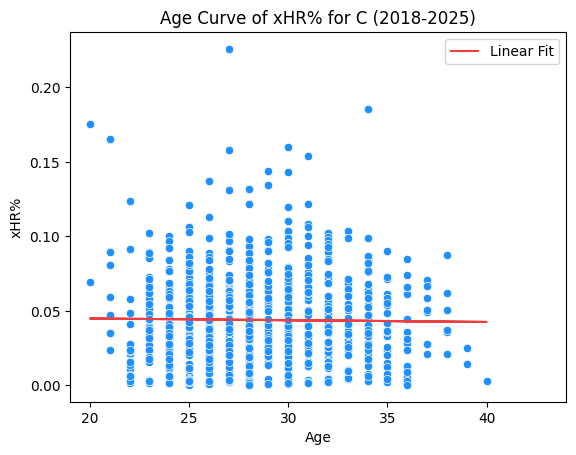

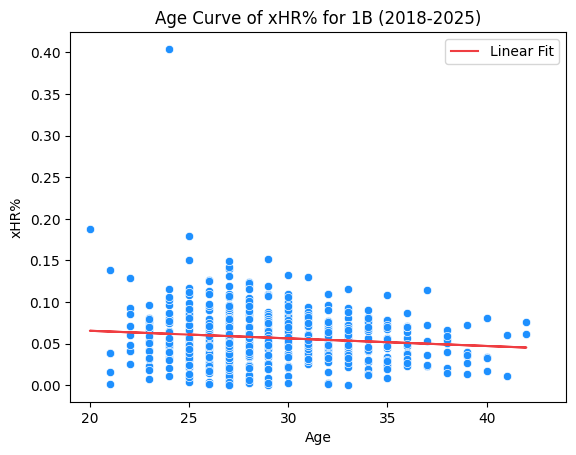

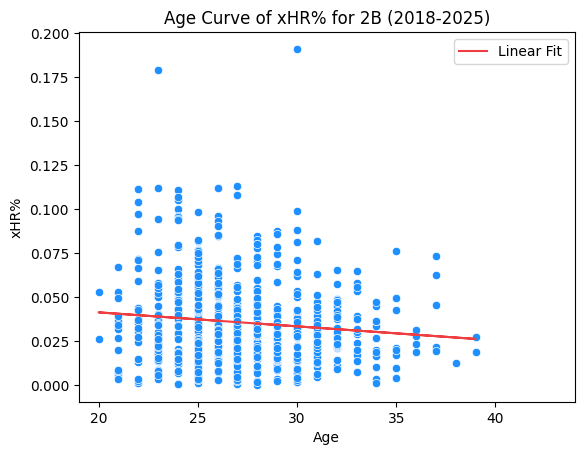

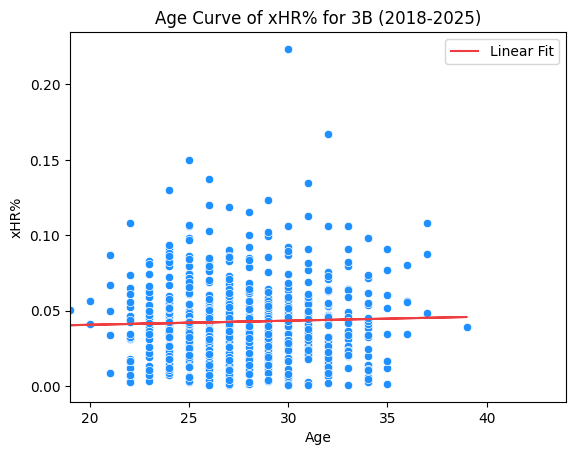

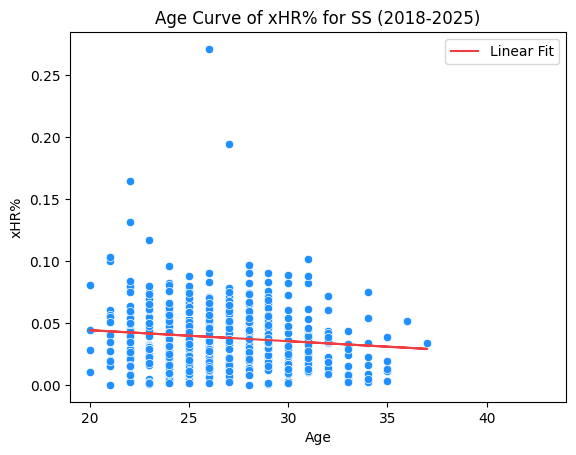

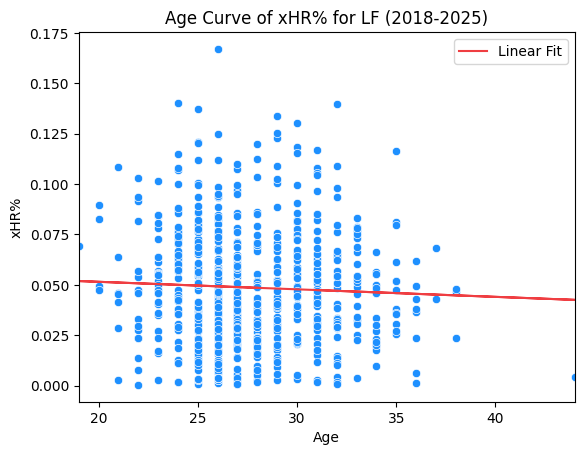

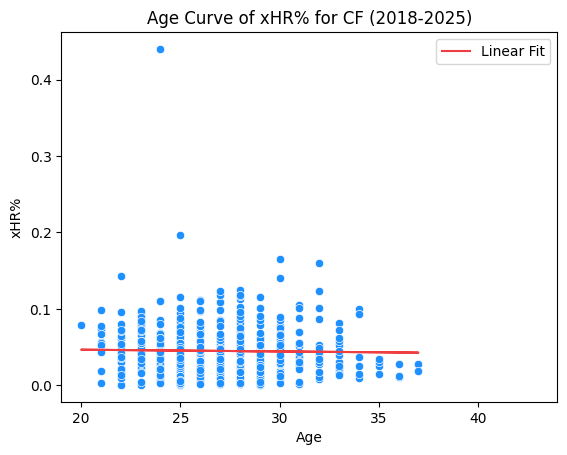

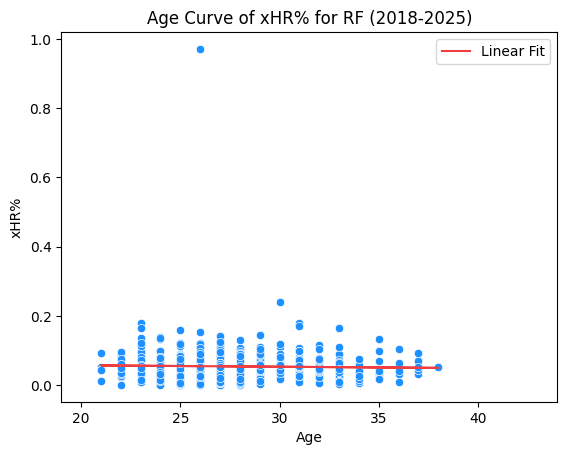

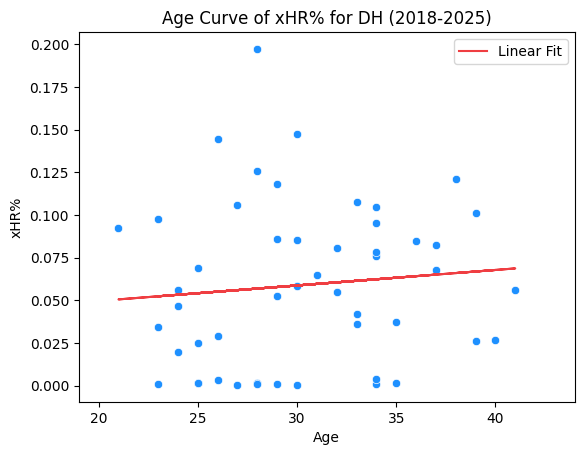

In [131]:
# age curve eda

plt.figure()
sns.scatterplot(data=player_data, x='Age', y='xHR%', color=blue_color)
m, b = np.polyfit(player_data['Age'], player_data['xHR%'], 1)
plt.plot(player_data['Age'], m*player_data['Age'] + b, color=red_color, label='Linear Fit')
plt.legend()
plt.title('Age vs xHR%')
plt.show()

for pos in possible_pos:
    pos_data = player_data[player_data['primary_pos'] == pos]
    plt.figure()
    sns.scatterplot(data=pos_data, x='Age', y='xHR%',color=blue_color)
    m_pos, b_pos = np.polyfit(pos_data['Age'], pos_data['xHR%'], 1)
    plt.plot(pos_data['Age'], m_pos*pos_data['Age'] + b_pos, color=red_color, label='Linear Fit')
    plt.title(f'Age Curve of xHR% for {pos} (2018-2025)')
    plt.legend()
    plt.xlim(player_data['Age'].min(), player_data['Age'].max())
    plt.show()

In [132]:
player_data['xHR%'].var()

np.float64(0.00110733978122369)

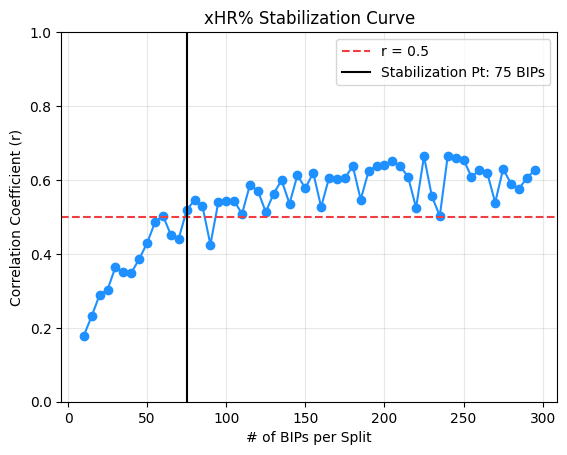

In [136]:
batted_ball_data = batted_ball_data.sort_values(by=['batter', 'game_year', 'game_date'], ascending=[True, True, True]).reset_index(drop=True).copy()
batted_ball_data['batted_ball_no'] = batted_ball_data.groupby(['batter', 'game_year']).cumcount() + 1

thresholds = np.arange(10, 300, 5)
corrs = []
stabilize_n = []

for n in thresholds:
    ## bucket 1 contains the first half of n batted balls
    bucket_1 = batted_ball_data[batted_ball_data['batted_ball_no'] <= n]
    rate_1 = bucket_1.groupby(['batter', 'game_year'])['xHR'].mean().rename('first_n')

    ## bucket 2 contains the second half of n batted balls
    bucket_2 = batted_ball_data[(batted_ball_data['batted_ball_no'] > n) & (batted_ball_data['batted_ball_no'] <= 2 * n)]
    rate_2 = bucket_2.groupby(['batter', 'game_year'])['xHR'].mean().rename('next_n')

    merged_rates = pd.concat([rate_1, rate_2], axis=1).dropna()
    r, p_val = pearsonr(merged_rates['first_n'], merged_rates['next_n'])
    corrs.append(r)
    stabilize_n.append(n)

for i in range(len(corrs) - 1):
    if corrs[i] >= 0.50 and corrs[i+1] >= 0.50:
        stabilization_pt = stabilize_n[i]
        break

plt.figure()
plt.plot(stabilize_n, corrs, marker='o', linestyle='-', color=blue_color)
plt.axhline(0.50, color=red_color, linestyle='--', label='r = 0.5')
plt.axvline(stabilization_pt, color='k', linestyle='-', label=f'Stabilization Pt: {stabilization_pt:.0f} BIPs')
plt.title("xHR% Stabilization Curve")
plt.xlabel("# of BIPs per Split")
plt.ylabel("Correlation Coefficient (r)")
plt.ylim(0, 1.0)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Data Prep for Modeling

In [137]:
# finds the team played for every player from every season 

team_data = []
for yr in list(np.arange(2018, 2026)):
    yr_data = batting_stats(yr, qual=1)
    yr_data = yr_data[['IDfg', 'Season', 'Team']]
    team_data.append(yr_data)
player_teams = pd.concat(team_data, ignore_index=True).copy()
## adds the team that the player played for in that season
player_data = (player_data
               .merge(player_teams, how='left', left_on=['IDfg', 'game_year'], right_on=['IDfg', 'Season'])
               .drop(columns=['Season'])
               .copy()
               )
player_data['Team'] = player_data['Team'].apply(lambda x: 'ATH' if x=='OAK' else '--' if x=='- - -' else x)
player_data = player_data.merge(park_long, how='left', left_on=['game_year', 'Team'], right_on=['game_year', 'team']).drop(columns=['Team'])
## we're making the assumption that the player plays half their game at that park --> only get half the park factor
player_data['park_factor'] = player_data['park_factor'].apply(lambda x: (x + 1)/2)

In [138]:
def create_lag_features(data, lag_amount):
    """
    fetches the lag years of the data (years j-1, j-2, j-3)
    """
    lag_df = data[['game_year', 'batter', 'events', 'pos_idx', 'xHR']].copy()
    ## shifts j forward so it aligns with j+1
    lag_df['game_year'] = lag_df['game_year'] + lag_amount
    lag_df = lag_df.rename(columns={'events': f'events_lag{lag_amount}', 
                                    'xHR': f'xHR_lag{lag_amount}',
                                    'pos_idx': f'pos_idx_lag{lag_amount}',
                                    })
    return lag_df

In [139]:
# label encoding the player pos
player_pos = player_data.copy()
pos_mapping = {'C': 0, '1B': 1, '2B': 2, '3B': 3, 'SS': 4, 'LF': 5, 'CF': 6, 'RF': 7, 'DH': 8}
player_pos['pos_idx'] = player_pos['primary_pos'].map(pos_mapping).astype(int)

## we're lagging the data so we can see the previous outcomes of the player in seasons j-1, ..., j-3 
player_data_lagged = player_pos.copy()
for i in [1, 2, 3]:
    lag_data = create_lag_features(player_pos, i)
    player_data_lagged = pd.merge(player_data_lagged, lag_data, on=['batter', 'game_year'], how='left').copy()
    
for i in [1, 2, 3]:
    ## if the lag position is missing, we assume they play their current position
    player_data_lagged[f'pos_idx_lag{i}'] = player_data_lagged[f'pos_idx_lag{i}'].fillna(player_data_lagged['pos_idx'])    
    player_data_lagged[f'events_lag{i}'] = player_data_lagged[f'events_lag{i}'].fillna(0)
    player_data_lagged[f'xHR_lag{i}'] = player_data_lagged[f'xHR_lag{i}'].fillna(0)

for col in player_data_lagged.columns:
    if 'pos_idx' in col:
        player_data_lagged[col] = player_data_lagged[col].astype(int)

## because we have the lagged results from the previous 3 seasons, we can exclude seasons 2018-2020
player_data_lagged = player_data_lagged[player_data_lagged['game_year'] >= 2021].reset_index(drop=True).copy()
player_data_lagged['batter_season'] = player_data_lagged['batter'].astype(str) + "_" + player_data_lagged['game_year'].astype(str) ## our coord system

## Modeling Implementations

In [140]:
def create_model_dict(df):
    """
    helper function that creates the data dictionary to be put into a numpyro model
    """
    return {'events': jnp.array(df['events'].values), 
            'HR': jnp.array(df['HR'].values), ## our target
            'park_factor': jnp.array(df['park_factor'].values),
            'pos_idx': jnp.array(df['pos_idx'].values),
            'age_splines': jnp.array(np.stack(df['age_splines'].values)),
            ## season j-1
            'events_lag1': jnp.array(df['events_lag1'].values),
            'xHR_lag1': jnp.array(df['xHR_lag1'].values),
            'pos_idx_lag1': jnp.array(df['pos_idx_lag1'].values),
            ## season j-2
            'events_lag2': jnp.array(df['events_lag2'].values),
            'xHR_lag2': jnp.array(df['xHR_lag2'].values),
            'pos_idx_lag2': jnp.array(df['pos_idx_lag2'].values),
            ## season j-3
            'events_lag3': jnp.array(df['events_lag3'].values),
            'xHR_lag3': jnp.array(df['xHR_lag3'].values), 
            'pos_idx_lag3': jnp.array(df['pos_idx_lag3'].values),
            }

In [141]:
# sets up the train (2021-2024) and validation set (2025) data dictionaries (holds our inputs for the model)

## generates the cubic B-spline matrix for modeling age curve
spline_matrix = patsy.dmatrix("0 + bs(Age, df=6, degree=3)", player_data_lagged, return_type='dataframe').values
player_data_lagged['age_splines'] = list(spline_matrix)

## splitting the data into a training (2021-24) and validation set (2025)
train_df = player_data_lagged[player_data_lagged['game_year'] < 2025].copy()
val_df = player_data_lagged[player_data_lagged['game_year'] == 2025].copy()

## the data dictionaries for each set
master_train = create_model_dict(train_df)
master_val = create_model_dict(val_df)

In [142]:
def hr_projection_model(events, park_factor, pos_idx, age_splines, 
                        events_lag1, xHR_lag1, pos_idx_lag1, 
                        events_lag2, xHR_lag2, pos_idx_lag2, 
                        events_lag3, xHR_lag3, pos_idx_lag3, 
                        HR=None):
    """
    bayesian hierarchical model for HR projections as discussed in the methodology Section 3.2 in the paper
    """
    n_obs = events.shape[0]
    n_pos = 9
    n_bases = 6 ## basis functions for the spline

    ## hyper priors for positional prior distributon --> our global population baseline
    mu = numpyro.sample("mu", dist.Normal(-3.0, 0.75))
    sigma = numpyro.sample("sigma", dist.HalfNormal(0.5))

    ## we model alpha_k as an expit function of z_k, which is our positional baseline
    ## we want to treat alpha_k as a random variable rather than a fixed one
    with numpyro.plate("positions", n_pos):
        z = numpyro.sample("z", dist.Normal(mu, sigma))
        alpha = numpyro.deterministic("alpha", expit(z))

    ## our stabilization point and acts as our shrinkage parameter
    ## represents the ratio of variances in the partial pooling equation
    M = numpyro.sample("M", dist.LogNormal(jnp.log(75.0), 0.25))

    ## our lagged weights for each previous season j-l, l = 1, 2, 3
    ## we hypothesize that the most recent season should take most of the weight
    beta = numpyro.sample("beta", dist.Dirichlet(jnp.array([6.0, 3.0, 1.0])))

    ## our age curve --> we used a cubic b-spline
    with numpyro.plate("pos_splines", n_pos, dim=-2):
        with numpyro.plate("bases", n_bases, dim=-1):
            ## our prior distribution on the basis function coefficients
            gamma = numpyro.sample("gamma", dist.Normal(0.0, 0.375)) 
    ## calculates the positional age effect for each player-season 
    f_k = jnp.sum(gamma[pos_idx] * age_splines, axis=-1)

    ## this serves as our adjusted estimate for a player's true talent estimated xHR total from each of the previous 3 seasons
    ## this adjustment is just a regression to the mean, in which players with small to zero N will fall towards alpha_k
    p_hat_1 = (xHR_lag1 + alpha[pos_idx_lag1] * M) / (events_lag1 + M)
    p_hat_2 = (xHR_lag2 + alpha[pos_idx_lag2] * M) / (events_lag2 + M)
    p_hat_3 = (xHR_lag3 + alpha[pos_idx_lag3] * M) / (events_lag3 + M)

    ## this applies each of the weights to the adjusted xHR estimate from season j-l
    ## this captures information of the player's previous seasons
    p_hist = beta[0] * p_hat_1 + beta[1] * p_hat_2 + beta[2] * p_hat_3

    ## we've done everything in the log odds (unbounded space) --> we want real probs [0, 1] space
    ## we use the expit AKA inverse-logit function to do this
    theta_logit = logit(p_hist) + f_k
    theta = numpyro.deterministic("theta", expit(theta_logit))

    ## park factor is already scaled as (BF + 1)/2
    ## adjusts theta, our latent true talent param, with park factor --> we already made the adjustment to park factor, so it's just a product
    p_adj = theta * park_factor

    ## our likelihood function --> we used a binomial process
    with numpyro.plate("data", n_obs):
        numpyro.sample("Y", dist.Binomial(total_count=events, probs=p_adj), obs=HR)

In [143]:
## defines the MCMC params
num_chains = 4
num_warmup = 1000
num_samples = 2000
## initalizes the NUTS sampler
nuts_kernel = NUTS(hr_projection_model)
mcmc = MCMC(nuts_kernel, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)
## runs MCMC with the training set dictionary (and seed 42)
mcmc.run(random.PRNGKey(seed), **master_train)

## grabs the ArviZ idata
idata = az.from_numpyro(mcmc)

## checks to make sure our sampler converged with the r_hat and ESS measures
summary_df = az.summary(idata)
display(summary_df['r_hat'].max())
display(summary_df['ess_bulk'].min())

## grabs the posterior samples (all 8,000)
posterior_samples = mcmc.get_samples()

sample: 100%|██████████| 3000/3000 [00:12<00:00, 243.26it/s, 15 steps of size 2.77e-01. acc. prob=0.85]


np.float64(1.0)

np.float64(5068.0)

In [144]:
# the predictions for every player in the held-out 2025 set

## just makes sure the predictions don't just echo the observations
val_inputs = {k: v for k, v in master_val.items() if k != "HR"}

## creates the predictions for the validation set
predictive = Predictive(hr_projection_model, posterior_samples)
predictions_2025 = predictive(jax.random.PRNGKey(seed), **val_inputs)
Y_pred_samples = np.array(predictions_2025["Y"]) ## predicted HRs per sample
actual_HR_2025 = np.array(master_val["HR"]) ## observed HRs per player

In [145]:
val_df[val_df['name'].str.contains('friedl')]

,game_year,batter,IDfg,name,Age,primary_pos,events,PA,HR,xHR,xHR%,team,park_factor,pos_idx,events_lag1,pos_idx_lag1,xHR_lag1,events_lag2,pos_idx_lag2,xHR_lag2,events_lag3,pos_idx_lag3,xHR_lag3,batter_season,age_splines
2918,2025,670770,19522,tj friedl,29,CF,473,685,14,12.453062,0.026328,CIN,1.14,6,250.0,6,7.969835,409.0,6,9.996245,191.0,5,7.490414,670770_2025,"[0.0, 0.006060606060606061, 0.7063576945929886..."


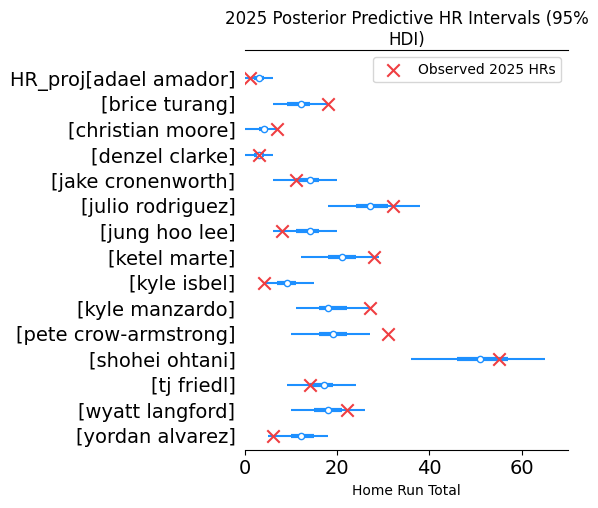

In [146]:
# the forest plot of each player's posterior predictive interval (95% HDIs)

selected_players = ['julio rodriguez',
                    'jake cronenworth',
                    'ketel marte',
                    'adael amador',
                    'denzel clarke',
                    'shohei ohtani',
                    'christian moore',
                    'jung hoo lee',
                    'pete crow-armstrong',
                    'kyle manzardo',
                    'wyatt langford',
                    'kyle isbel',
                    'tj friedl',
                    'brice turang',
                    'yordan alvarez'
                    ]

## gets the idx of the selected players in the list
sample_idx = np.where(val_df['name'].isin(selected_players))[0]

## grabs the predictions of every sample, observed HRs, and name for every player
sample_preds = Y_pred_samples[:, sample_idx]
sample_actuals = actual_HR_2025[sample_idx]
sample_names = val_df.iloc[sample_idx]['name'].values

## we put the predictions in an ArviZ object like in PyMC
pred_idata = az.from_dict(posterior_predictive={"HR_proj": np.expand_dims(sample_preds, axis=0)}, 
                          coords={"player": sample_names}, 
                          dims={"HR_proj": ["player"]}
                          )

## the forest plot
fig, ax = plt.subplots(figsize=(6, 5))
axes = az.plot_forest(pred_idata.posterior_predictive, var_names=["HR_proj"], combined=True, colors=blue_color, hdi_prob=0.95, ax=ax)
axes[0].scatter(sample_actuals[::-1], axes[0].get_yticks(), color=red_color, marker='x', s=80, zorder=10, label="Observed 2025 HRs")
axes[0].set_title("2025 Posterior Predictive HR Intervals (95% HDI)")
axes[0].set_xlabel("Home Run Total")
# axes[0].set_yticklabels(sample_names[::-1])
axes[0].set_xlim(0, 70)
axes[0].legend()
plt.tight_layout()
plt.savefig("../plots/fig_intervals.png", format="png", dpi=300)
plt.show()

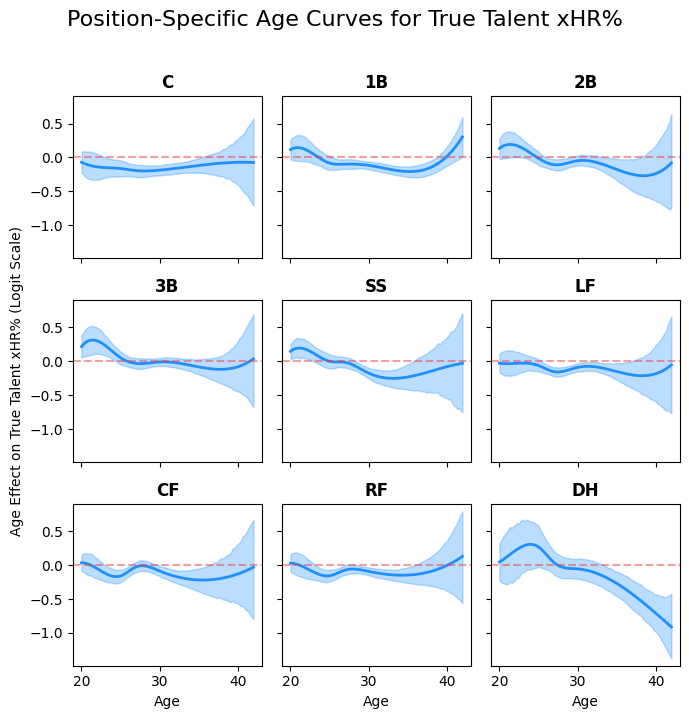

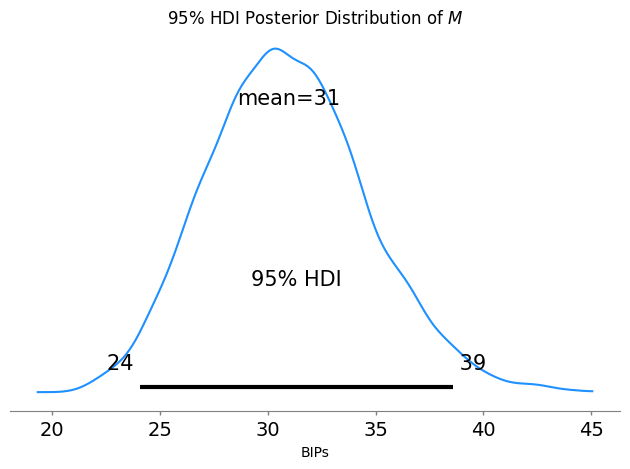

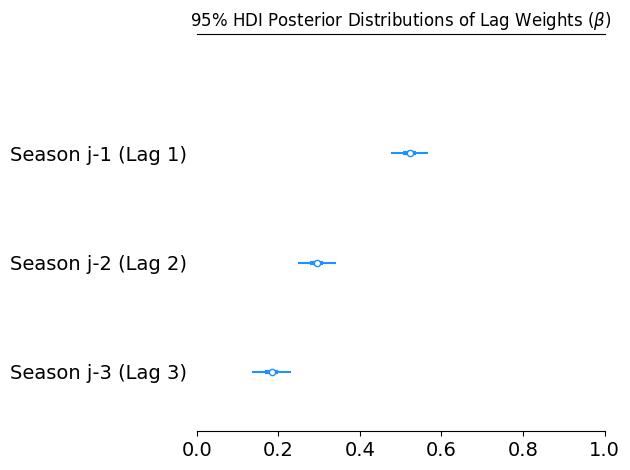

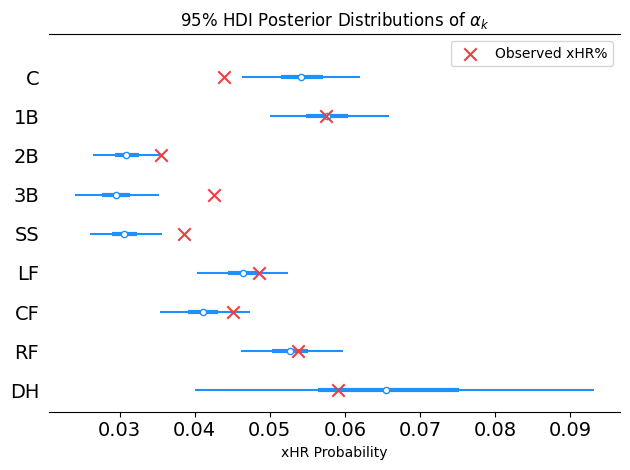

In [147]:
# plots the posterior distributions for each parameter

# age curve
ages = np.linspace(20, 42, 100)
age_df = pd.DataFrame({'Age': ages})
## spline basis with the same knots from the data
orig_spline = patsy.dmatrix("0 + bs(Age, df=6, degree=3)", player_data_lagged, return_type='dataframe')
spline_grid = patsy.build_design_matrices([orig_spline.design_info], age_df)[0]
spline_grid = np.asarray(spline_grid)
## the estimated gamma coeficients for each sample 
gamma_samples = posterior_samples['gamma']
## 3x3 grid plot for each position
pos_labels = ["C", "1B", "2B", "3B", "SS", "LF", "CF", "RF", "DH"]
fig, axes = plt.subplots(3, 3, figsize=(7, 7), sharex=True, sharey=True)
axes = axes.flatten()

for k in range(9):
    ## samples * 100
    age_effect_k = gamma_samples[:, k, :] @ spline_grid.T
    age_effect_k = np.array(age_effect_k)
    ## posterior mean and 95% for the age curve
    age_curve_mean = age_effect_k.mean(axis=0)
    reshaped_effects = age_effect_k.reshape(num_chains, num_samples, -1)
    age_curve_hdi = az.hdi(reshaped_effects, hdi_prob=0.95)
    
    ax = axes[k]
    ax.plot(ages, age_curve_mean, color=blue_color, lw=2)
    ax.fill_between(ages, age_curve_hdi[:, 0], age_curve_hdi[:, 1], color=blue_color, alpha=0.3)
    ax.axhline(0, color=red_color, linestyle='--', alpha=0.5) 
    ax.set_title(pos_labels[k], fontsize=12, fontweight='bold')
    if k >= 6:
        ax.set_xlabel("Age")
    if k == 3:
        ax.set_ylabel(r"Age Effect on True Talent xHR% (Logit Scale)")
plt.suptitle("Position-Specific Age Curves for True Talent xHR%", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("../plots/fig_age_curves.png", format="png", bbox_inches="tight")
plt.show()

# M - shrinkage param
fig, ax = plt.subplots()
az.plot_posterior(idata, var_names=["M"], hdi_prob=0.95, point_estimate="mean", color=blue_color, ax=ax)
ax.set_title("95% HDI Posterior Distribution of $M$")
ax.set_xlabel("BIPs")
plt.tight_layout()
plt.savefig("../plots/fig_M_posterior.png", format="png", dpi=300)
plt.show()

# lag beta params --> our dirichlet prior params
lag_labels = ["Season j-1 (Lag 1)", "Season j-2 (Lag 2)", "Season j-3 (Lag 3)"]
fig, ax = plt.subplots()
axes = az.plot_forest(idata, var_names=["beta"], combined=True, colors=blue_color, hdi_prob=0.95, ax=ax)
axes[0].set_yticklabels(lag_labels[::-1])
axes[0].set_title("95% HDI Posterior Distributions of Lag Weights ($\\beta$)")
axes[0].set_xlim(0, 1)
plt.tight_layout()
plt.savefig("../plots/fig_beta_weights.png", format="png", dpi=300)
plt.show()

# alpha_k --> the positional baseline 
pos_labels = ["C", "1B", "2B", "3B", "SS", "LF", "CF", "RF", "DH"]
obs_means = player_data.groupby('primary_pos')['xHR%'].mean()
obs_pos_means = [obs_means[pos] for pos in pos_labels][::-1]

fig, ax = plt.subplots()
axes = az.plot_forest(idata, var_names=["alpha"], colors=blue_color, combined=True, hdi_prob=0.95, ax=ax)
axes[0].scatter(obs_pos_means, axes[0].get_yticks(), color=red_color, marker='x', s=80, zorder=10, label="Observed xHR%")
axes[0].set_yticklabels(pos_labels[::-1])
axes[0].set_title(r"95% HDI Posterior Distributions of $\alpha_k$")
axes[0].set_xlabel("xHR Probability")
axes[0].legend(loc='upper right')
plt.tight_layout()
plt.savefig("../plots/fig_alpha_k.png", format="png", dpi=300)
plt.show()

## Model Comparison (Ours vs Steamer's and ZiPS')

In [148]:
posterior_means = Y_pred_samples.mean(axis=0)

## grabs everything into a df
projections_df = pd.DataFrame({'batter': val_df['batter'].values, 
                               'name': val_df['name'].values, 
                               'projected_HR_mean': posterior_means, 
                               'observed_HR': actual_HR_2025
                               })
projections_df = projections_df.sort_values(by='projected_HR_mean', ascending=False).reset_index(drop=True)

# the zips and steamer projections --> we grabbed these from fangraphs (and paid for it)

## zips
zips_2025_proj = pd.read_csv('../data/zips_2025.csv').copy()
zips_2025_proj = zips_2025_proj[['Name', 'Team', 'HR', 'PlayerId', 'MLBAMID']]
zips_2025_proj = zips_2025_proj.rename(columns={'HR': 'zips_HR'})

## steamer
steamer_2025_proj = pd.read_csv('../data/steamer_2025.csv').copy()
steamer_2025_proj = steamer_2025_proj[['Name', 'Team', 'HR', 'PlayerId', 'MLBAMID']]
steamer_2025_proj = steamer_2025_proj.dropna(subset=['MLBAMID'])
steamer_2025_proj['MLBAMID'] = steamer_2025_proj['MLBAMID'].astype(int)
steamer_2025_proj = steamer_2025_proj.rename(columns={'HR': 'steamer_HR'})

## combined projections
public_projs = steamer_2025_proj.merge(zips_2025_proj[['zips_HR', 'MLBAMID']], how='left', on='MLBAMID')
public_projs = public_projs[~public_projs['zips_HR'].isna()].reset_index(drop=True).copy()
public_projs = public_projs[['MLBAMID', 'Name', 'Team', 'steamer_HR', 'zips_HR']]
proj_comparison = public_projs.merge(projections_df[['batter', 'projected_HR_mean']], how='left', left_on='MLBAMID', right_on='batter')
proj_comparison = proj_comparison[~proj_comparison['projected_HR_mean'].isna()].reset_index(drop=True)
## adds age and observed HRs
proj_comparison = proj_comparison.merge(player_data_lagged[player_data_lagged['game_year'] == 2025][['batter', 'Age', 'HR']], how='left', on='batter')

## age comparison
young_players = proj_comparison[proj_comparison['Age'] <= 26]
old_players = proj_comparison[proj_comparison['Age'] > 26]

In [149]:
def rmse(df, proj_hr):
    return np.sqrt(np.mean((df[proj_hr] - df['HR']) ** 2))

def mae(df, proj_hr):
    return np.mean(np.abs(df[proj_hr] - df['HR']))

metrics = []
for model, col in [('steamer', 'steamer_HR'), ('zips', 'zips_HR'), ('ours', 'projected_HR_mean')]:
    for group_name, group_df in [('young', young_players), ('old', old_players), ('all', proj_comparison)]:
        metrics.append({'model': model,
                        'group': group_name,
                        'rmse': round(rmse(group_df, col), 2),
                        'mae': round(mae(group_df, col), 2),
                        })

proj_comparison_df = pd.DataFrame(metrics).set_index('model')
proj_comparison_df

,group,rmse,mae
model,,,
steamer,young,6.25,4.52
steamer,old,6.28,4.23
steamer,all,6.27,4.35
zips,young,8.64,7.36
zips,old,7.98,6.22
zips,all,8.26,6.68
ours,young,4.08,2.77
ours,old,4.41,2.93
ours,all,4.28,2.86


## Data Prep for 2026 Projections

In [150]:
def normalize_name(s):
    """
    normalize names: lowercase, remove spaces after periods, strip accents
    """
    s = s.lower()
    s = re.sub(r"\.\s*", ".", s)
    s = unicodedata.normalize('NFKD', s)
    return ''.join(c for c in s if not unicodedata.combining(c))

In [ ]:
# the 2026 projected data from fangraphs -> Depth Charts
# https://www.fangraphs.com/roster-resource/opening-day-tracker?status=40man
projected_2026_data = pd.read_excel('../data/roster-resource__opening-day-tracker.xlsx')

## excludes pitchers
pitcher_pos = ['SP', 'RP', 'SP/RP']
weird_pos = ['INF/OF', 'INF', 'OF', 'OF/INF', 'C/INF', '1B/OF', '1B/3B', 'UTL', 'C/1B', 'OF/1B']
projected_2026_data = projected_2026_data[~projected_2026_data['Pos'].isin(pitcher_pos)].reset_index(drop=True).copy()
projected_2026_data = projected_2026_data[projected_2026_data['Proj PA'] > 0].reset_index(drop=True).copy()
projected_2026_data = projected_2026_data[['Team', 'Name', 'Pos', 'Age', 'Proj PA', 'MLBAMID']]
projected_2026_data = projected_2026_data.rename(columns={'Proj PA': 'PA_proj',
                                                          'Name': 'Name_proj',
                                                          'Team': 'Team_proj',
                                                          'Pos': 'Pos_proj',
                                                          'Age': 'Age_proj'})

# adding 2026 dummy states for the player_data df
player_data = player_data[~player_data['team'].isna()].reset_index(drop=True).copy()
players_2025 = player_data[player_data['game_year'] == 2025].reset_index(drop=True).copy()
df_2026 = players_2025.copy() ## we're building out a dummy 2026 set
df_2026['game_year'] = 2026
df_2026['Age'] = df_2026['Age'] + 1
df_2026['events'] = np.nan
df_2026['PA'] = np.nan
df_2026['HR'] = np.nan
df_2026['xHR'] = np.nan
df_2026['xHR%'] = np.nan
df_2026['team'] = np.nan
df_2026['park_factor'] = np.nan
player_data_w_2026 = pd.concat([player_data, df_2026], ignore_index=True).copy()

# merging the two dfs to get the projected stuff for the 2026 season
df_merged = player_data_w_2026.merge(projected_2026_data, how='left', left_on='batter', right_on='MLBAMID',)
is_2026 = df_merged['game_year'] == 2026
update_condition = (is_2026) & (~df_merged['Pos_proj'].isin(weird_pos)) & (df_merged['Pos_proj'].notna())
df_merged['primary_pos'] = np.where(update_condition, df_merged['Pos_proj'], df_merged['primary_pos'])
df_merged['PA'] = np.where(is_2026, df_merged['PA_proj'], df_merged['PA'])
df_merged['team'] = np.where(is_2026, df_merged['Team_proj'], df_merged['team'])
df_merged['events'] = np.where(is_2026, np.nan, df_merged['events'])
df_merged['park_factor'] = np.where(is_2026, np.nan, df_merged['park_factor'])
player_data_w_2026 = df_merged.drop(columns=['MLBAMID', 'IDfg', 'Team_proj', 'Pos_proj', 'Age_proj', 'PA_proj', 'Name_proj'])

# all of the new players that are projected to debut in 2026 and adding them to the data
players_w_history_ids = player_data_w_2026['batter'].to_list()
new_players_2026 = projected_2026_data[~projected_2026_data['MLBAMID'].isin(players_w_history_ids)].reset_index(drop=True).copy()
new_players_2026['game_year'] = 2026
new_players_2026['events'] = np.nan
new_players_2026['HR'] = np.nan
new_players_2026['xHR'] = np.nan
new_players_2026['xHR%'] = np.nan
new_players_2026['park_factor'] = np.nan
new_players_2026 = new_players_2026.rename(columns={'PA_proj': 'PA',
                                                    'Name_proj': 'name',
                                                    'Team_proj': 'team',
                                                    'Pos_proj': 'primary_pos',
                                                    'Age_proj': 'Age',
                                                    'MLBAMID': 'batter',
                                                    })
new_players_2026['Age'] = new_players_2026['Age'].apply(lambda x: round(x)) ## rounds to nearest integer
new_players_2026['name'] = new_players_2026['name'].apply(normalize_name)
new_players_2026 = new_players_2026[['game_year', 'batter', 'name', 'Age', 'primary_pos', 'events', 'PA', 'HR', 'xHR', 'xHR%', 'team', 'park_factor']]

## i grabbed these from baseball reference and just seeing what they played most pre-MLB
pos_updates = {'junior perez': {'primary_pos': 'CF'},
                'tyler austin': {'primary_pos': '1B'},
                'james triantos': {'primary_pos': '2B'},
                'ben cowles': {'primary_pos': 'SS'},
                'tanner murray': {'primary_pos': '3B'},
                'edwin arroyo': {'primary_pos': 'SS'},
                'hector rodriguez': {'primary_pos': 'LF'},
                'juan brito': {'primary_pos': '2B'},
                'kahlil watson': {'primary_pos': 'CF'},
                'sterlin thompson': {'primary_pos': 'LF'},
                'trei cruz': {'primary_pos': 'SS'},
                'hao-yu  lee': {'primary_pos': '3B'},
                'eduardo valencia': {'primary_pos': '1B'},
                'ryan ward': {'primary_pos': 'LF'},
                'deyvison de los santos': {'primary_pos': '1B'},
                'jared serna': {'primary_pos': 'SS'},
                'emmanuel rodriguez': {'primary_pos': 'CF'},
                'gabriel gonzalez': {'primary_pos': 'RF'},
                'spencer jones': {'primary_pos': 'CF'},
                'gabriel rincones jr.': {'primary_pos': 'RF'},
                'sung-mun song': {'primary_pos': '3B'},
                'jesus rodriguez': {'primary_pos': 'C'},
                'joshua baez': {'primary_pos': 'RF'},
                'bryan torres': {'primary_pos': '2B'},
                'cesar prieto': {'primary_pos': '3B'},
                'brandon valenzuela': {'primary_pos': 'C'},
                'christian franklin': {'primary_pos': 'LF'},
                }
flat_pos_dict = {player: data['primary_pos'] for player, data in pos_updates.items()}
mapped_positions = new_players_2026['name'].map(flat_pos_dict)
new_players_2026['primary_pos'] = np.where(mapped_positions.notna(), new_players_2026['name'].map(flat_pos_dict), new_players_2026['primary_pos'])

## adds the new players to the overall dataset
player_data_w_2026 = pd.concat([player_data_w_2026, new_players_2026]).reset_index(drop=True).copy()

## gets rid of any current free agents who aren't signed to a team or aren't projected to be on the major league roster
player_data_w_2026 = player_data_w_2026[~((player_data_w_2026['game_year'] == 2026) & player_data_w_2026['PA'].isna())].reset_index(drop=True)

player_data_w_2026 = (player_data_w_2026
                      .sort_values(by=['name', 'game_year'], ascending=[True, True])
                      .reset_index(drop=True).copy()
                      )

## grabs Depth Charts' projected batted ball events
depth_charts_proj_2026 = pd.read_csv('../data/depth_charts_2026_proj.csv').copy()
depth_charts_proj_2026['bips'] = depth_charts_proj_2026['PA'] - (depth_charts_proj_2026['SO'] + 
                                                                   depth_charts_proj_2026['BB'] + 
                                                                   depth_charts_proj_2026['HBP'] + 
                                                                   depth_charts_proj_2026['IBB']
                                                                   )
depth_charts_proj_2026 = depth_charts_proj_2026[['MLBAMID', 'bips']].copy()

# beginning the cleaning of the 2026 set

is_2026 = player_data_w_2026['game_year'] == 2026

## making the 2026 projected PAs integers
player_data_w_2026['PA'] = player_data_w_2026['PA'].astype(int)

## updates the park factors
player_data_w_2026 = player_data_w_2026.drop(columns=['park_factor'])
player_data_w_2026 = player_data_w_2026.merge(park_long, how='left', left_on=['game_year', 'team'], right_on=['game_year', 'team'])
player_data_w_2026['park_factor'] = player_data_w_2026['park_factor'].apply(lambda x: (x + 1)/2)

## updates the projected number of batted ball events for each player --> taken from DepthCharts
player_data_w_2026 = player_data_w_2026.merge(depth_charts_proj_2026, how='left', left_on = 'batter', right_on = 'MLBAMID')
player_data_w_2026['events'] = player_data_w_2026['events'].fillna(player_data_w_2026['bips'])

player_data_w_2026['events'] = player_data_w_2026['events'].astype(int)

player_data_w_2026 = player_data_w_2026.drop(columns=['MLBAMID', 'bips']).copy()

In [225]:
# label encoding the player pos
player_pos_2026 = player_data_w_2026.copy()
player_pos_2026['pos_idx'] = player_pos_2026['primary_pos'].map(pos_mapping).astype(int)

## we're lagging the data so we can see the previous outcomes of the player in seasons j-1, ..., j-3 
player_data_lagged_2026 = player_pos_2026.copy()
for i in [1, 2, 3]:
    lag_data_2026 = create_lag_features(player_pos_2026, i)
    player_data_lagged_2026 = pd.merge(player_data_lagged_2026, lag_data_2026, on=['batter', 'game_year'], how='left').copy()
    
for i in [1, 2, 3]:
    ## if the lag position is missing, we assume they play their current position
    player_data_lagged_2026[f'pos_idx_lag{i}'] = player_data_lagged_2026[f'pos_idx_lag{i}'].fillna(player_data_lagged_2026['pos_idx'])    
    player_data_lagged_2026[f'events_lag{i}'] = player_data_lagged_2026[f'events_lag{i}'].fillna(0)
    player_data_lagged_2026[f'xHR_lag{i}'] = player_data_lagged_2026[f'xHR_lag{i}'].fillna(0)

for col in player_data_lagged_2026.columns:
    if 'pos_idx' in col:
        player_data_lagged_2026[col] = player_data_lagged_2026[col].astype(int)

## we want to train on 2022-2025 to predict 2026 --> we can omit players from seasons < 2022
player_data_lagged_2026 = player_data_lagged_2026[player_data_lagged_2026['game_year'] >= 2022].reset_index(drop=True).copy()
player_data_lagged_2026['batter_season'] = player_data_lagged_2026['batter'].astype(str) + "_" + player_data_lagged_2026['game_year'].astype(str) ## our coord system

In [228]:
player_data_lagged_2026.to_parquet('../data/player_data_lagged_2026.parquet')